## ИИММ: практическая работа 3


Суть задания: 

На лекции вы познакомились с историей архитектур нейронных сетей. В этом блокноте мы будем реализовывать одну из самых важных архитектур CNN за последние несколько лет - ResNet.

План работы:
1. Загрузка данных.
2. Полносвязная нейронная сеть.
3. Базовая сверточная нейронная сеть.
4. Использование ResNet для классификации.
5. Оптимизация гиперпараметров и другие трюки.

In [1]:
import time
import os

import torch
import torchvision
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchsummary import summary

from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision.utils import make_grid
from torchvision import transforms as T
from torchvision import models, datasets

from tqdm.notebook import tqdm

import numpy as np
from matplotlib import pyplot as plt
from random import randint

In [2]:
!pip3 install numpy matplotlib

### Этап 1. Загрузка данных

In [4]:
batch_size = 32
data_root = './data/cifar10'
transform = T.Compose([
    T.ToTensor(), # открывает изображения как тензоры со значениями в диапазоне [0, 1]
    # Масштабирует значения пикселей в диапазон [-1, 1]
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Мы установим разделение 80-20 для проверки обучения.
# То есть мы выделим 80 % из 50 тыс. образцов в обучающих данных CIFAR10 в качестве обучающего набора.
# а оставшиеся 20 % - в качестве валидационного набора
train_size = 40_000
val_size = 10_000

dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)
assert train_size + val_size <= len(dataset), "Trying to sample too many elements!" \
    "Please lower the train or validation set sizes."
train_set, val_set, _ = torch.utils.data.random_split(
    dataset, [train_size, val_size, len(dataset) - train_size - val_size]
)
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
)

In [5]:
# Этот блок создаст загрузчики данных PyTorch, связанные с обучающим и проверочным наборами.
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

showing training images


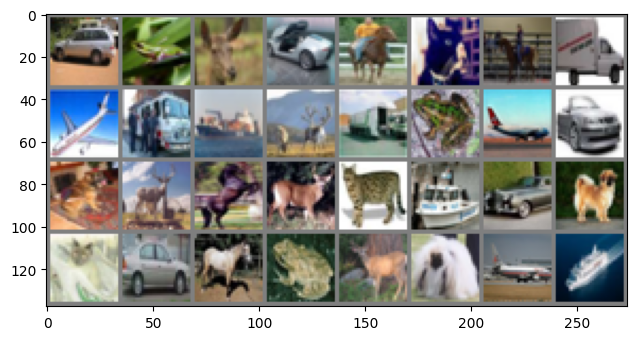


... and their corresponding labels
car      frog     deer     car      horse    cat      horse    truck   
plane    truck    ship     deer     truck    frog     plane    car     
dog      deer     horse    deer     cat      ship     car      dog     
cat      car      horse    frog     deer     dog      plane    ship    


In [6]:
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [7.5, 7.5]

def show_image(img):
    img = img / 2 + 0.5
    img = img.numpy()
    img = img.transpose([1, 2, 0])
    plt.imshow(img)
    plt.show()

images, labels = next(iter(train_loader))
nrow = 4
print('showing training images')
show_image(torchvision.utils.make_grid(images, nrow=batch_size // nrow))
print('\n... and their corresponding labels')
for idxs in np.array_split(np.arange(batch_size), nrow):
    print(' '.join(f'{classes[labels[j]]:8s}' for j in idxs))

### Этап 2. Полносвязная нейронная сеть

In [7]:
class FCNN(nn.Module):
    def __init__(self, layer_dims):
        '''
        Инициализируйте torch.nn.Module и определите несколько слоев для дальнейшего использования
        layer_dims: список целых чисел: первое целое число является входным размером
            а все последующие элементы представляют собой ширину
            каждого слоя в нашей NN. Для простоты можно предположить.
            что len(layer_dims) == 3.
        Например, если layer_dims = [100, 50, 10], то этот многослойный
        перцептрон будет состоять из двух линейных слоев: первый слой будет принимать
        входы размерности 100 и выходные тензоры размерности 50, а второй слой
        будет принимать входные данные размерности 50 и выводить тензоры размерности
        размерности 10
        '''
        ## YOUR CODE HERE

        super().__init__()
        self.flatten = nn.Flatten()
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(layer_dims[0], layer_dims[1])
        self.fc2 = nn.Linear(layer_dims[1], layer_dims[2])

        ## TODO: Не забывайте о вызове super!
        ## TODO: Создайте несколько линейных слоев, которые можно будет вызывать
        ## при определении forward pass ниже.
        ## Вы можете либо захардкодить, что будет 3 слоя,
        ## либо можно обратиться к torch.nn.ModuleList()

        ## END YOUR CODE

    def forward(self, x):
        '''
        Вычислите прямой проход по пакету изображений

        x: torch.Tensor of shape (batch_size, num_channels, width, height)
        возвращает: результат прохождения x через вашу сеть
        '''
        ## YOUR CODE HERE

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

        ## TODO: Сплющите изображения; помните, что x - это целый батч!
        ## TODO: Примените каждый из слоев и ReLU после каждого из них.

        ## END YOUR CODE

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def compute_accuracy(model, loader):
    total_correct = 0

    ## YOUR CODE HERE

    model = model.to(device)
    model.eval()

    ## TODO: Поместите модель на нужное устройство (CPU/GPU)
    ## TODO: Включите режим оценивания (eval) для модели

    ## END YOUR CODE

    for inputs, labels in tqdm(loader, leave=False):
        ## YOUR CODE HERE

        inputs = inputs.to(device); labels = labels.to(device)
        scores = model(inputs)
        total_correct += (torch.argmax(scores, 1) == labels).sum()

        ## TODO: Переместите входные данные (inputs) и метки (labels) на правильное устройство
        ## TODO: Вычислите выходы модели
        ## TODO: Подсчитайте количество правильных предсказаний (подсказка: используйте torch.argmax)
        ## TODO: Обновите общее количество правильных предсказаний

        ## END YOUR CODE
    return total_correct / len(loader.dataset)

def train(model, train_loader, val_loader, num_epochs, criterion, optimizer, path=None, scheduler=None):
    print('beginning to train model')
    if path and not os.path.exists(path):
      os.makedirs(path)

    ## YOUR CODE HERE

    model = model.to(device)

    ## TODO: Поместите модель на нужное устройство (CPU/GPU)

    ## END YOUR CODE

    for epoch in tqdm(range(1, num_epochs + 1)):
        model.train()
        total_loss = 0
        start_time = time.perf_counter()
        for inputs, labels in tqdm(train_loader, leave=False):
            ## YOUR CODE HERE

            inputs = inputs.to(device); labels = labels.to(device)
            optimizer.zero_grad()
            scores = model(inputs)
            loss = criterion(scores, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss

            ## TODO: Переместите входные данные (inputs) и метки (labels) на правильное устройство
            ## TODO: Обнулите градиенты
            ## TODO: Вычислите выходы модели
            ## TODO: Рассчитайте функцию потерь (loss)
            ## TODO: Выполните обратное распространение градиентов с учетом функции потерь
            ## TODO: Выполните шаг оптимизатора
            ## TODO: Обновите общий loss, добавив текущий loss

            ## END YOUR CODE

        if path:
          torch.save(model.state_dict(), f'{path}/model_ep_{epoch:02d}.pth')
        end_time = time.perf_counter()
        duration = end_time - start_time

        ## YOUR CODE HERE

        train_acc = compute_accuracy(model, train_loader)
        val_acc = compute_accuracy(model, val_loader)

        ## TODO: Вычислите точность (accuracy) для обучения и валидации (подсказка: используйте `compute_accuracy()`).

        ## END YOUR CODE

        current_lr = optimizer.param_groups[0]['lr']

        if scheduler and current_lr > 5e-5:
            scheduler.step()

        print(f'epoch {epoch:2}',
              f'loss: {total_loss:.3f}',
              f'time: {duration:.3f}',
              f'train acc: {train_acc:.4f}',
              f'val acc: {val_acc:.4f}', sep='\t')

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [12]:
num_epochs = 15
layer_dims = [3072, 100, 10]
fcnn = FCNN(layer_dims)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(fcnn.parameters(), lr=1e-3, momentum=0.9)

In [13]:
train(fcnn, train_loader, val_loader, num_epochs, criterion, optimizer)

beginning to train model


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch 14	loss: 1462.315	time: 11.836	train acc: 0.6156	val acc: 0.5157


  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

epoch 15	loss: 1436.520	time: 12.957	train acc: 0.6183	val acc: 0.5113


In [14]:
print(count_parameters(fcnn))

308310


## Этап 3. Базовая сверточная нейронная сеть

In [18]:
class CNN(nn.Module):
    def __init__(self):
        '''
        Инициализируйте `torch.nn.Module` и определите несколько слоев для дальнейшего использования.

        Пожалуйста, используйте следующую структуру сети:
        - сверточный слой с 5 выходными каналами и размером ядра 5
        - max pooling на блоках 2x2 с шагом 2
        - сверточный слой с 16 выходными каналами и размером ядра 5
        - max pooling на блоках 2x2 с шагом 2
        - линейный (полносвязный) слой со 120 выходными измерениями
        - линейный (полносвязный) слой с 84 выходными измерениями
        - линейный (полносвязный) слой с 10 выходными измерениями

        После любого сверточного или линейного слоя, КРОМЕ финального выходного, используйте активацию ReLU.
        '''
        ## YOUR CODE HERE

        super().__init__()
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.mp = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=5, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=5, out_channels=16, kernel_size=5)
        self.fc1 = nn.Linear(in_features=(16 * 5 * 5), out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)

        ## END YOUR CODE

    def forward(self, x):
        '''
        Выполните прямой проход (forward pass) батча изображений. Обратитесь к docstring для метода `init`, чтобы узнать порядок, в котором входные данные проходят через слои.

        x: torch.Tensor формы (batch_size, num_channels, width, height)
        returns: результат прохождения x через вашу сеть
        '''
        ## YOUR CODE HERE

        x = self.conv1(x)
        x = self.relu(x)
        x = self.mp(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.mp(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

        ## TODO: Вызовите сверточные слои с активацией и пуллингом.
        ## TODO: Выпрямите (flatten) выход, чтобы его можно было передать в линейные слои.
        ## TODO: Вызовите линейные слои с активацией.
        ## TODO: Не забудьте НЕ использовать активацию после финального полносвязного слоя!

        ## END YOUR CODE

In [19]:
num_epochs = 15
cnn = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn.parameters(), lr=1e-3, momentum=0.9)

In [20]:
train(cnn, train_loader, val_loader, num_epochs, criterion, optimizer)

beginning to train model


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch 14	loss: 1343.893	time: 22.106	train acc: 0.6391	val acc: 0.5934


  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

epoch 15	loss: 1304.745	time: 22.323	train acc: 0.6438	val acc: 0.5979


## Этап 4. Использование ResNet для классификации

In [3]:
class ResNetBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        '''
        Создайте остаточный (residual) блок для архитектуры ResNet18.

        Ожидаемая структура сети:
        - сверточный слой с параметрами:
          - число выходных каналов = out_channels, ядро 3x3, шаг (stride) = stride
        - слой BatchNorm
        - сверточный слой с параметрами:
          - число выходных каналов = out_channels, ядро 3x3, шаг (stride) = 1
        - слой BatchNorm
        - shortcut слой:
          - если шаг (stride) не равен 1 или out_channels не равен in_channels:
            shortcut слой состоит из двух шагов:
            - сверточный слой с параметрами:
              - число входных каналов = in_channels, число выходных каналов = out_channels, ядро 3x3, шаг (stride) = stride
            - слой BatchNorm
          - иначе:
            shortcut слой не выполняет никаких операций (no-op).

        Все сверточные слои должны иметь паддинг 1 и не должны использовать смещение (bias term). Для удобства рассмотрите использование
        предоставленной вспомогательной функции `conv()`.

        При выполнении прямого прохода (forward pass) активация ReLU должна применяться:
        - после первого слоя BatchNorm
        - после добавления второго слоя BatchNorm к shortcut.
        '''
        ## YOUR CODE HERE

        super().__init__()
        self.relu = nn.ReLU()
        self.conv1 = self.conv(in_channels, out_channels, kernel_size=3, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = self.conv(out_channels, out_channels, kernel_size=3, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                self.conv(in_channels, out_channels, kernel_size=3, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        ## TODO: Инициализируйте блок с вызовом super и создайте сверточные и batchnorm слои.
        ## TODO: Используйте условную логику при определении shortcut слоя.
        ## Для слоя, не выполняющего операций (no-op), рассмотрите создание пустого nn.Sequential().

        ## END YOUR CODE

    def conv(self, in_channels, out_channels, kernel_size, stride):
        return nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding=1, bias=False)

    def forward(self, x):
        '''
        Выполните прямой проход (forward pass) этого батча данных через остаточный блок.

        x: батч изображений формы (batch_size, num_channels, width, height)
        returns: результат прохождения x через этот блок
        '''
        ## YOUR CODE HERE

        result = self.conv1(x)
        result = self.bn1(result)
        result = self.relu(result)
        result = self.conv2(result)
        result = self.bn2(result)
        result += self.shortcut(x)
        result = self.relu(result)

        return result

        ## TODO: Вызовите первый сверточный слой, batchnorm и активацию
        ## TODO: Вызовите второй сверточный слой и batchnorm
        ## TODO: Также примените shortcut слой к исходным входным данным
        ## TODO: Сложите результат shortcut слоя и результат второго batchnorm,
        ## затем примените активацию
        ## TODO: Верните результат

        ## END YOUR CODE

class ResNet18(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3,
                               out_channels=64,
                               kernel_size=3,
                               stride=1,
                               padding=1,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.in_channels = 64
        self.layer1 = self.make_block(out_channels=64, stride=1, rep=2)
        self.layer2 = self.make_block(out_channels=128, stride=2, rep=2)
        self.layer3 = self.make_block(out_channels=256, stride=2, rep=2)
        self.layer4 = self.make_block(out_channels=512, stride=2, rep=2)
        self.linear = nn.Linear(512, num_classes)

    def make_block(self, out_channels, stride, rep):
        layers = []
        for stride in [stride, 1]:
            layers.append(ResNetBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = F.avg_pool2d(x, 4)
        x = torch.flatten(x, 1)
        x = self.linear(x)
        return x

In [22]:
num_epochs = 15
resnet = ResNet18(num_classes = 10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=1e-3, momentum=0.9)

In [23]:
resnet = resnet.to(device)
summary(resnet, input_size = (3, 32, 32), batch_size=32)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 64, 32, 32]           1,728
       BatchNorm2d-2           [32, 64, 32, 32]             128
            Conv2d-3           [32, 64, 32, 32]          36,864
       BatchNorm2d-4           [32, 64, 32, 32]             128
              ReLU-5           [32, 64, 32, 32]               0
            Conv2d-6           [32, 64, 32, 32]          36,864
       BatchNorm2d-7           [32, 64, 32, 32]             128
              ReLU-8           [32, 64, 32, 32]               0
       ResNetBlock-9           [32, 64, 32, 32]               0
           Conv2d-10           [32, 64, 32, 32]          36,864
      BatchNorm2d-11           [32, 64, 32, 32]             128
             ReLU-12           [32, 64, 32, 32]               0
           Conv2d-13           [32, 64, 32, 32]          36,864
      BatchNorm2d-14           [32, 64,

In [24]:
train(resnet, train_loader, val_loader, num_epochs, criterion, optimizer, 'checkpoints_resnet')

beginning to train model


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

...

epoch 14	loss: 9.815	time: 55.813	train acc: 0.9999	val acc: 0.8182


  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

epoch 15	loss: 9.036	time: 39.666	train acc: 0.9998	val acc: 0.8023


## Этап 5. Оптимизация гиперпараметров и другие трюки

In [4]:
batch_size = 32

In [5]:
try:
    import shutil
    shutil.rmtree("./data")
    del train_loader, val_loader
except:
    pass

In [6]:


data_root = './data/cifar10'
train_size = 40_000
val_size = 10_000

mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

transform_train = T.Compose([
    T.Normalize(mean, std),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
])

## YOUR CODE HERE
## TODO: Измените указанные преобразования и гиперпараметры, если хотите
## Не удаляйте T.Normalize. Если вы хотите изменить нормализацию,
## измените списки mean и std ниже.

## END YOUR CODE

transform_val = T.Compose([
    T.Normalize(mean, std),
])

dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=T.ToTensor()
)

assert train_size + val_size <= len(dataset), "Trying to sample too many elements!" \
    "Please lower the train or validation set sizes."
train_split, val_split, _ = torch.utils.data.random_split(
    range(len(dataset)), [train_size, val_size, len(dataset) - train_size - val_size]
)

class CustomTransformDataset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.transform = transform
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        return self.transform(x), y

train_set = CustomTransformDataset(dataset, train_split, transform=transform_train)
val_set = CustomTransformDataset(dataset, val_split, transform=transform_val)

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

100%|██████████| 170M/170M [01:09<00:00, 2.46MB/s] 


In [ ]:

plt.rcParams['figure.figsize'] = [7.5, 7.5]

def show_image(img):
    mean_tensor = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
    std_tensor = torch.tensor(std, dtype=torch.float32).view(-1, 1, 1)
    img = img * std_tensor + mean_tensor
    img = img.numpy()
    img = img.transpose([1, 2, 0])
    plt.imshow(img)
    plt.show()

images, labels = next(iter(train_loader))
nrow = 8
print('showing training images')
show_image(torchvision.utils.make_grid(images, nrow=batch_size // nrow))
print('\n... and their corresponding labels')
classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
)
for idxs in np.array_split(np.arange(batch_size), nrow):
    print(' '.join(f'{classes[labels[j]]:8s}' for j in idxs))

In [7]:
final_cnn = ResNet18(num_classes=10)
final_cnn = final_cnn.to(device)

In [ ]:
## YOUR CODE HERE
## TODO: Измените гиперпараметры по желанию
num_epochs = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_cnn.parameters(), lr=1e-3)
## Вы также можете добавить планировщик скорости обучения (learning rate scheduler), если хотите поэкспериментировать с ним
scheduler = None  # Измените это значение, если хотите использовать планировщик (необязательно)
## END YOUR CODE

train(final_cnn, train_loader, val_loader, num_epochs, criterion, optimizer, 'checkpoints_final_cnn', scheduler)

beginning to train model


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1250 [00:00<?, ?it/s]